In [1]:
import minari
import numpy as np

dataset = minari.load_dataset("D4RL/pointmaze/umaze-v2", download=True)
print("Num episodes:", dataset.total_episodes)

# minari.list_remote_datasets()

namespace_metadata.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


main_data.hdf5:   0%|          | 0.00/556M [00:00<?, ?B/s]


Dataset D4RL/pointmaze/umaze-v2 downloaded to C:\Users\Owner\.minari\datasets\D4RL\pointmaze\umaze-v2
Num episodes: 13210


In [2]:
trajectories = []

for ep in dataset.iterate_episodes():
    trajectories.append({
        "observations": ep.observations,
        "actions": ep.actions,
        "rewards": ep.rewards,
        "terminals": ep.terminations,   # correct Minari field
        "length": len(ep.observations)
    })

print("Num trajectories:", len(trajectories))
print("Example trajectory length:", trajectories[0])
print("Example shape:", np.array(trajectories[0]["observations"]).shape)

Num trajectories: 13210
Example trajectory length: {'observations': {'achieved_goal': array([[-1.15781409, -1.16204705],
       [-1.15543246, -1.15966541],
       [-1.15067485, -1.15584774],
       [-1.14354694, -1.14965752],
       [-1.13405437, -1.14190278],
       [-1.12220276, -1.13366593],
       [-1.10799774, -1.12433977],
       [-1.09144492, -1.11505646],
       [-1.07254988, -1.10578321],
       [-1.0513182 , -1.09415041],
       [-1.02775545, -1.08261363],
       [-1.00186718, -1.07010922],
       [-0.97365893, -1.05754274],
       [-0.94313622, -1.04738783],
       [-0.91030457, -1.03963874],
       [-0.87516947, -1.0338358 ],
       [-0.83773642, -1.03042832],
       [-0.79801087, -1.02794923],
       [-0.7559983 , -1.02560759],
       [-0.71170415, -1.0223998 ],
       [-0.66513386, -1.01909239],
       [-0.61629284, -1.0181745 ],
       [-0.5651865 , -1.01636125],
       [-0.51361337, -1.0146086 ],
       [-0.46135081, -1.01243791],
       [-0.41176374, -1.00789075],
    

In [14]:
import numpy as np

trajectories_clean = []

for ep in dataset.iterate_episodes():

    obs = ep.observations

    obs_vec = np.array(obs["observation"])         # (T, 4)
    ag = np.array(obs["achieved_goal"])            # (T, 2)
    dg = np.array(obs["desired_goal"])             # (T, 2)
    actions = np.array(ep.actions)                 # (T, 2)

    # concatenate full state
    states = np.concatenate([obs_vec, ag, dg], axis=-1)  # (T, 8)

    trajectories_clean.append({
        "states": states,
        "actions": actions,
        "length": len(states)
    })

print("Num traj:", len(trajectories_clean))
print("State shape:", trajectories_clean[0]["states"].shape)
print("Action shape:", trajectories_clean[0]["actions"].shape)

Num traj: 13210
State shape: (163, 8)
Action shape: (162, 2)


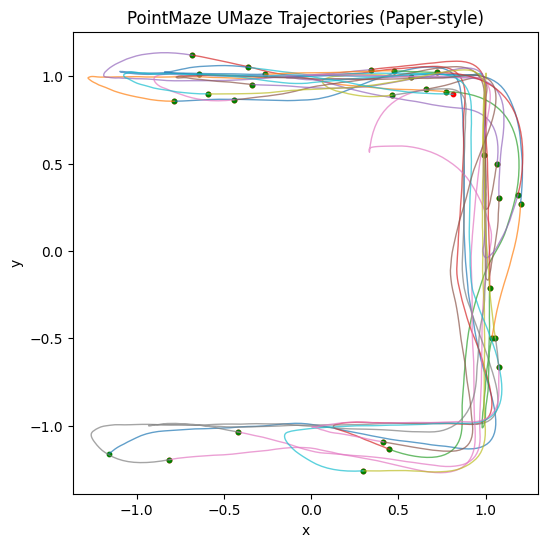

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def paper_style_plot(trajectories, num_traj=30):

    plt.figure(figsize=(6,6))

    for traj in trajectories[:num_traj]:
        states = traj["states"]
        xy = states[:, :2]

        plt.plot(xy[:,0], xy[:,1], linewidth=1, alpha=0.7)

        plt.scatter(xy[0,0], xy[0,1], c="green", s=10)
        plt.scatter(xy[-1,0], xy[-1,1], c="red", s=10)

    plt.title("PointMaze UMaze Trajectories (Paper-style)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(False)
    plt.show()

paper_style_plot(trajectories_clean)

In [ ]:
import gymnasium_robotics
import gymnasium as gym
# env = gym.make("PointMaze_UMaze-v3", render_mode="rgb_array")
env = dataset.recover_environment(render_mode='human')
# env.unwrapped.model.vis.global_.offwidth = 500
# env.unwrapped.model.vis.global_.offheight = 500
obs, _ = env.reset()

# plt.imshow(obs)
# plt.axis('off') # Hide axes for 2D look
# plt.show()

img = env.render()
plt.imshow(img)

for traj in trajectories_clean[:10]:
    xy = traj["states"][:, :2]
    plt.plot(xy[:,0], xy[:,1], linewidth=1)

plt.show()

TypeError: Image data of dtype object cannot be converted to float

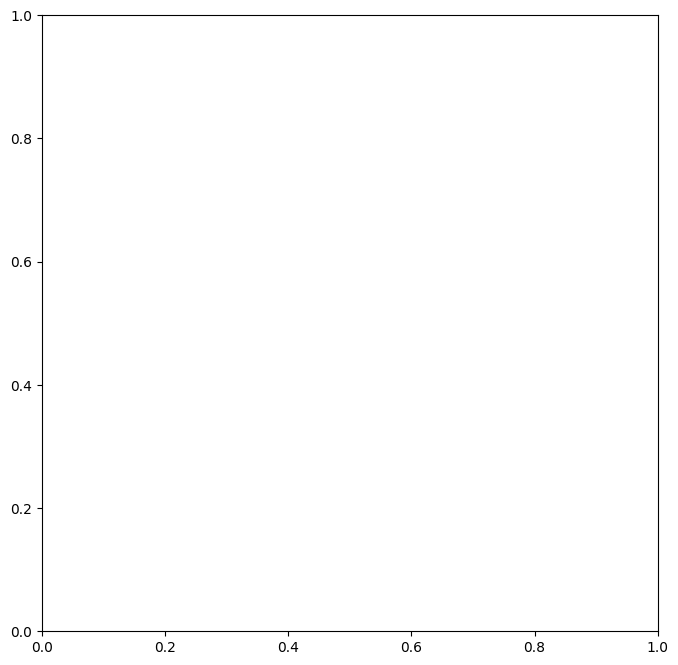

In [47]:
import matplotlib.pyplot as plt

# Reset to ensure the environment is initialized
obs, info = env.reset()

# Force the 2D top-down camera (PointMaze typically uses camera_id=0 or -1 for top-down)
# If your Gymnasium version supports arguments in render:
frame = env.render() 

# FIX: If frame is a list, take the first element
if isinstance(frame, list):
    frame = frame[0]

plt.figure(figsize=(8, 8))
plt.imshow(frame)
plt.axis('off')
plt.show()
